# Datasets and Tokenizers
Demonstration of fast data loading and tokenization, visualized.

In [1]:
from datasets import load_dataset
from transformers import AutoTokenizer
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load a dataset
dataset = load_dataset("imdb", split="train[:1000]")
print(dataset)

Dataset({
    features: ['text', 'label'],
    num_rows: 1000
})


/var/folders/11/3wm066fn49g0hkx1gf8m5jc40000gn/T/ipykernel_57638/3211392685.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="label", palette="viridis")


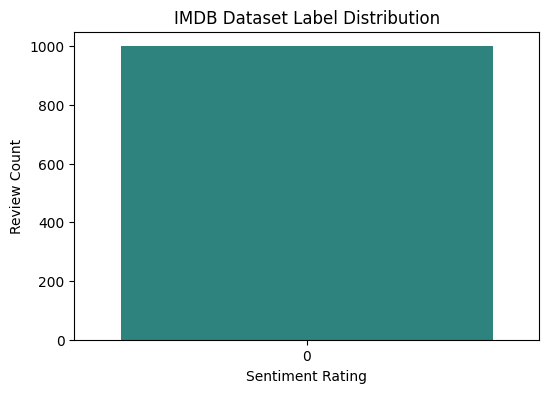

In [2]:
# Visualize the label distribution
df = dataset.to_pandas()
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="label", palette="viridis")
plt.title("IMDB Dataset Label Distribution")
plt.xlabel("Sentiment Rating")
plt.ylabel("Review Count")
plt.show()

In [3]:
# Load a fast tokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
print(f"Is fast tokenizer: {tokenizer.is_fast}")

Is fast tokenizer: True


Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

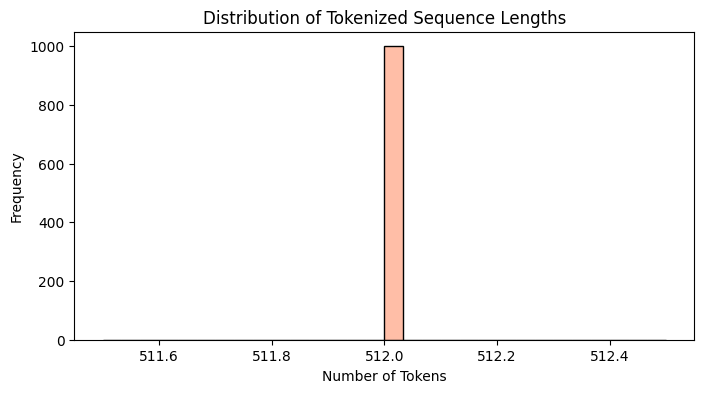

In [4]:
# Tokenize the dataset using map
def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True)

tokenized_dataset = dataset.map(tokenize_function, batched=True)

# Visualize token lengths
df["token_length"] = [len(x) for x in tokenized_dataset["input_ids"]]
plt.figure(figsize=(8, 4))
sns.histplot(df["token_length"], bins=30, kde=True, color="coral")
plt.title("Distribution of Tokenized Sequence Lengths")
plt.xlabel("Number of Tokens")
plt.ylabel("Frequency")
plt.show()